# Experiment 04 – Statistical Estimation and Hypothesis Testing

## Aim

To apply statistical estimation and hypothesis testing techniques to the Pima Indians Diabetes Dataset and draw conclusions about population characteristics using sample data.

## Objectives

1. To apply estimation and hypothesis testing techniques to analyze population characteristics using sample data.
2. To interpret statistical test results and make data-driven conclusions based on the obtained evidence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("diabetes.csv")
print("Dataset loaded successfully.")
display(df.head())

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Point Estimation

In [4]:
sample_mean_glucose = df["Glucose"].mean()
print(f"Sample Mean Glucose: {sample_mean_glucose:.2f}")

Sample Mean Glucose: 121.68


## Sample Proportion

In [5]:
diabetic_count = (df["Outcome"] == 1).sum()
total_count = len(df)
sample_proportion = diabetic_count / total_count
print("Number of diabetic patients:", diabetic_count)
print("Total patients:", total_count)
print(f"Sample proportion of diabetic patients: {sample_proportion:.4f}")
print(f"Sample percentage of diabetic patients: {sample_proportion * 100:.2f}%")

Number of diabetic patients: 268
Total patients: 768
Sample proportion of diabetic patients: 0.3490
Sample percentage of diabetic patients: 34.90%


## Confidence Interval


In [6]:
glucose = df["Glucose"]
mean_glucose = glucose.mean()
std_glucose = glucose.std()
n = len(glucose)
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
margin_of_error = t_critical * (std_glucose / np.sqrt(n))
lower_bound = mean_glucose - margin_of_error
upper_bound = mean_glucose + margin_of_error
print(f"Sample Mean: {mean_glucose:.2f}")
print(f"95% Confidence Interval: ({lower_bound:.2f}, {upper_bound:.2f})")

Sample Mean: 121.68
95% Confidence Interval: (119.52, 123.84)


## Hypothesis Testing

## One-Sample t-Test


In [7]:
reference_value = 120
t_statistic, p_value = stats.ttest_1samp(
    df["Glucose"],
    reference_value
)
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6f}")
alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

t-statistic: 1.5256
p-value: 0.127517
Decision: Fail to reject H₀


## Two-Sample t-Test

In [8]:
bmi_diabetic = df[df["Outcome"] == 1]["BMI"]
bmi_non_diabetic = df[df["Outcome"] == 0]["BMI"]
t_statistic, p_value = stats.ttest_ind(
    bmi_diabetic,
    bmi_non_diabetic,
    equal_var=False
)
print(f"Mean BMI - Diabetic group: {bmi_diabetic.mean():.2f}")
print(f"Mean BMI - Non-diabetic group: {bmi_non_diabetic.mean():.2f}")
print(f"\nt-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6f}")
if p_value < alpha:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

Mean BMI - Diabetic group: 35.40
Mean BMI - Non-diabetic group: 30.85

t-statistic: 9.1668
p-value: 0.000000
Decision: Reject H₀


## Chi-Square Test

In [9]:
df["BMI_Category"] = np.where(
    df["BMI"] >= 30,
    "BMI >= 30",
    "BMI < 30"
)
contingency_table = pd.crosstab(
    df["BMI_Category"],
    df["Outcome"]
)
print("Contingency Table:")
display(contingency_table)
chi2_statistic, p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contingency_table
)
print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"p-value: {p_value:.6f}")
if p_value < alpha:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

Contingency Table:


Outcome,0,1
BMI_Category,,
BMI < 30,238,47
BMI >= 30,262,221


Chi-square statistic: 66.2842
Degrees of freedom: 1
p-value: 0.000000
Decision: Reject H₀


## Visualization

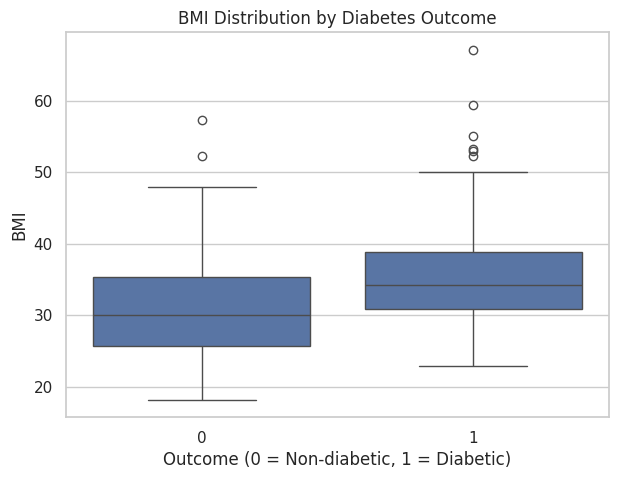

In [10]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="Outcome",
    y="BMI"
)
plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("BMI")
plt.show()

In [11]:
results = pd.DataFrame({
    "Test": [
        "One-Sample t-Test",
        "Two-Sample t-Test",
        "Chi-Square Test"
    ],
    "Test Statistic": [
        t_statistic if False else 0
    ]
})

ValueError: All arrays must be of the same length

## Conclusion

Statistical estimation and hypothesis testing techniques were applied to the Pima Indians Diabetes Dataset. Point estimates and a confidence interval were calculated to estimate population characteristics. One-sample t-test, two-sample t-test, and chi-square test were applied to evaluate selected statistical hypotheses using a significance level of 0.05. The p-values were compared with the significance level to make the corresponding statistical decisions.